<img src=https://surfdrive.surf.nl/public.php/dav/files/AXyGmKdZK3P6bie/logo_cci.jpg>


<img src=https://surfdrive.surf.nl/public.php/dav/files/AXyGmKdZK3P6bie/Vegetation_Parameters_CCI_posk.jpg width="200">

## 1. Introduction
In this notebook, we demonstrate the use of the Vegetation CCI+ datasets for various applications. The Vegetation CCI datasets contain 21-year long time series of vegetation parameters dervied from mulitiple satellite missions combined. The datasets provide the essential climate variables of Leaf Area Index (LAI) and the fraction of absorbed photosynthetically active radiation (fAPAR). Additional variables of the the vegetation are available as well, for selected sites globally. These include the albedo's, chlorophyll and carotenoid pigment content, and in the near future also products derived from solar induced fluorescence (SIF).
This notebook focusses on the second climate data record, CRPD-2. This product has a spatial resolution of 1/112 degrees (approximately 1 km at the equator), a temporal resolution of 5 days, a spatial coverage of Europe and part of Africa, and a temporal coverage of the period 2000-2020.
The purpose of this notebook is to familiarize you with the data and provide first steps and examples of the use of the data in various applications.

## 2. Import Necessary Packages

In this section, we import the required Python packages to work with ESA Climate Change Initiative (CCI) data. 

We ideally use the [ESA Climate Toolbox](https://esa-climate-toolbox.readthedocs.io/en/latest/) which simplifies access, manipulation, and visualization of CCI datasets in Python. However, at the time of preparation of the training, the required dataset (CRPD-2) was not available in the climate data store yet. For this reason we provide an alternative to access part of the data to run this exercise.

The ESA Climate Toolbox packages allow us to:
- Access satellite-based climate data records from ESA.
- Handle geospatial and temporal dimensions efficiently.
- Visualize data with intuitive plotting tools.

📚 For a broader introduction to the toolbox and how to install it, visit:  
🔗 [ESA CCI Climate Toolbox Quick Start](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks)  
🔗 [ESA Climate Data Toolbox Website](https://climate.esa.int/en/data/toolbox/)

In this notebook, we focus on the Vegetation CCI+ dataset.
Note: you may need to pip install some the below if modules are not found

## 3 Data access
The CCI Vegetatation datasets are available in the following ways:
[CEDA](https://data.ceda.ac.uk/neodc/esacci/vegetation_parameters/data/L3S/vp_products/v2.0)
or: <br>
Climate data store with data_id = 'esacci.VEGETATION.5-days.L3S.VP_PRODUCTS.VEGETATION.multi-platform.MERGED.v1-0.r1' <br>
__At the time of writing, the climate data store only provides the first dataset (CRDP-1), which is now superseded by the second, joint sensor dataset (CRPD-2). Access to CRDP-2 through the Climate Data Store may be available soon.__

As a temporal solution, we provide access of a small subset of the second dataset through the following [link](https://surfdrive.surf.nl/s/AXyGmKdZK3P6bie). This link is available until 31 December 2026. The link contains the data to run this notebook. 
This dataset is only available for the purpose of this training, and should not be used for scientific work. Use the official release on CEDA or the climate data store instead, once these data are made publicly available.

You can find complete documentation about the vegetation CCI project [here](https://climate.esa.int/en/projects/vegetation-parameters/). 

In [1]:
import xarray as xr
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from datetime import datetime, timedelta
from netCDF4 import Dataset
from xcube.core.store import new_data_store
from esa_climate_toolbox.core import get_op
from esa_climate_toolbox.core import list_ecv_datasets
from esa_climate_toolbox.core import get_store
from esa_climate_toolbox.core import list_datasets
from esa_climate_toolbox.ops import plot
import xarray as xr
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean

# extra, only needed for download from URL (not for climate data toolbox)
import wget

# to display images
from IPython.display import Image
from IPython.core.display import HTML 

%matplotlib inline

## 4. Working with selected tiles
After following the steps below, you are able to:<br>
- find a tile of interest<br>
- access the tile of the Vegetation CCI+ CRPD-2 dataset<br>
- select variables (data layers) of interest from the dataset<br>
- visualize the data<br>
- interpret and use the quality flag<br>
- perform basic spatial aggregetation from 1 km to 0.1 degree resolution

The dataset consists of tiles of data, each 10x10 degrees lat/lon, and containing 1120x1120 pixels of 1/112 degrees each. The map below shows the tiles that are included in CRDP-2 <BR>
In this notebook, we will look at data of central Europe, tile X18Y03, and compare the summers of 2017 and 2018. In the northern part of this area, a drought occurred in 2018, see for example [Peters et al. (2020)](https://doi.org/10.1098/rstb.2019.0505).

In the next step, we select the dates of 30 July 2017 and 30 July 2018, and find the closest date in the time series. The data have a temporal resolution of 5 daysm and 30 July is included. We will generate the file name and get the file.

<img src=https://surfdrive.surf.nl/public.php/dav/files/AXyGmKdZK3P6bie/tiles_map.png width="600">
<i>Side note: In the temporal dataset provided in the link above, the tile numbers start from 01 in the northernmost row instead of from 00. This means the vertical tile numbers in this notebook need to be increased by 1. This is not the case in the official dataset on CEDA or the climate data toolbox that we are using below!</i>

The data are avaiable for 5 day intervals, counting from January 1.

The first date where data is available is 2000-01-01, and the last date is 2020su-12-31.

The code below "rounds" the date that is requested by the user to the closest date where data is available (the closest multiple of 5 days is computed), and generates the file name we are looking for.


In [43]:
tile = 'X19Y02'

In [44]:
# the following is the base_url for the CEDA dataset of CRPD-1 and CPDP-2 (CRPD-1 is superseded by CRPD-2)
#base_url = 'https://dap.ceda.ac.uk/neodc/esacci/vegetation_parameters/data/L3S/vp_products/v1.0/transect'
#base_url = 'https://dap.ceda.ac.uk/neodc/esacci/vegetation_parameters/data/L3S/vp_products/v2.0/transect'
# the following is the temporal link to the CRPD-2 dataset, at the time of preparing this notebook they were not yet available on CEDA. Change this ULR once the CEDA dataset is available. 
# Or, alternatively, use the ESA climate data toolbox
base_url = 'https://surfdrive.surf.nl/s/AXyGmKdZK3P6bie'
base_url = 'https://surfdrive.surf.nl/public.php/dav/files/AXyGmKdZK3P6bie'
base_url = 'https://dap.ceda.ac.uk/neodc/esacci/vegetation_parameters/data/L3S/vp_products/v2.0/tiles'

for yr in range(2017, 2019):
    d = datetime(yr,7,30)
    print('Requested date:', d.strftime('%Y'), d.strftime('%m'), d.strftime('%d'))
    # Find closest date that is a multiple of 5 days starting at January 1
    julian_day = d.timetuple().tm_yday
    mul_5_julian_day = 1 + 5 * int((julian_day - 1) / 5)
    closest_mul_5_julian_day = mul_5_julian_day if julian_day - mul_5_julian_day < 3 else mul_5_julian_day + 5
    delta = closest_mul_5_julian_day - julian_day
    delta = timedelta(days = delta)
    d = d + delta
    year = d.strftime('%Y')
    month = d.strftime('%m')
    day = d.strftime('%d')
    print('Closest date:', year, month, day)
    
    filename = 'ESACCI-VEGETATION-L3S-VP_PRODUCTS-MERGED-tile_' + tile + '-' + year + month + day + '-fv2.0.nc'
    
    # this is the folder structure for CEDA (organized per year and per tile). Uncomment, and comment next line, when downloading from CEDA.
    url = base_url + '/' + year + '/' + tile + '/' + filename  
    # in the temporal folder, the data are not organized per year and per tile:
    #url = base_url + '/' + filename    
    print(url)
    print(base_url)
    wget.download(url)

Requested date: 2017 07 30
Closest date: 2017 07 30
https://dap.ceda.ac.uk/neodc/esacci/vegetation_parameters/data/L3S/vp_products/v2.0/tiles/2017/X19Y02/ESACCI-VEGETATION-L3S-VP_PRODUCTS-MERGED-tile_X19Y02-20170730-fv2.0.nc
https://dap.ceda.ac.uk/neodc/esacci/vegetation_parameters/data/L3S/vp_products/v2.0/tiles
100% [..........................................................................] 9425483 / 9425483Requested date: 2018 07 30
Closest date: 2018 07 30
https://dap.ceda.ac.uk/neodc/esacci/vegetation_parameters/data/L3S/vp_products/v2.0/tiles/2018/X19Y02/ESACCI-VEGETATION-L3S-VP_PRODUCTS-MERGED-tile_X19Y02-20180730-fv2.0.nc
https://dap.ceda.ac.uk/neodc/esacci/vegetation_parameters/data/L3S/vp_products/v2.0/tiles
100% [..........................................................................] 8171092 / 8171092

We have now downloaded the data of one tile for two dates. We can now inspect the content of the data, by printing the dimension names and variable names of the NetCDF files.

In [46]:
nc_fid = Dataset(filename)
dimensions = nc_fid.dimensions
variables = nc_fid.variables
print(list(dimensions.keys()))
print(list(variables.keys()))
nc_fid

['time', 'lat', 'lon', 'nbnds']
['lon_bnds', 'lat_bnds', 'time_bnds', 'crs', 'lat', 'lon', 'time', 'LAI', 'LAI_ERR', 'fAPAR', 'fAPAR_ERR', 'LAI_fAPAR_correl', 'n_bands_used', 'p_chisquare', 'invcode']


<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    doi: 10.5285/8d02d224437247f6a6270a575d457bd8
    title: ESA CCI Vegetation Parameters LAI, fAPAR
    institution: VITO
    source: Top-of-Canopy reflectance and uncertainty from multiple sensors. For description, see https://climate.esa.int/media/documents/VP-CCI_D2.1_ATBD_V2.2.pdf
    history: 2025-07-19 12:40:14 - Product generated by OptiSAIL r39569M
2026-04-07 16:43:19 - Final product packaging by cciv_packager.py 2.0
    references: ATBD: https://climate.esa.int/media/documents/VP-CCI_D2.1_ATBD_V2.2.pdf
    tracking_id: b58eba36-8789-40e0-9119-c452e0a11f8a
    Conventions: CF-1.8
    product_version: V2.0
    format_version: CCI Data Standards v2.3
    keywords: satellite, observation, vegetation, multi-sensor, multi-angular
    id: ESACCI-VEGETATION-L3S-VP_PRODUCTS-MERGED-tile_X19Y02-20180730-fv2.0.nc
    naming_authority: vegetation_parameters.esa-cci
    keywords_vocabulary: science keywords
    c

We will now extract the following data layers into arrays: Leaf area Index ('LAI') and its uncertainty ('LAI_ERR'), the fraction of absorbed photochemical radiation ('fAPAR') and its uncertainty ('fAPAR_ERR'), and the quality flag ('invcode').

In [53]:
#files = sorted(glob(r"*X19Y03*.nc")) # temporal link above
files = sorted(glob(r"*X19Y02*.nc")) # CEDA

print(files)
times2 = np.zeros((len(files),1), dtype="datetime64[s]")

vars = ['fAPAR', 'fAPAR_ERR', 'LAI', 'LAI_ERR']

for i, fp in enumerate(files, start=0): 
    print(fp)
    ds = xr.open_dataset(fp)  
    invcode = ds['invcode']  
    invcode = np.squeeze(invcode.values)
 
    for k in range(2):
        subset = ds[vars[2*k]]
        subset_err = ds[vars[2*k+1]]
               
        var = np.squeeze(subset.values)
        var_err = np.squeeze(subset_err.values)
        if k ==0:
            if i==0:
                fAPAR2 = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
                fAPAR_err2 = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
                LAI2 = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
                LAI_err2 = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
                QF2 = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
            fAPAR2[:,:,i] = var
            fAPAR_err2[:,:,i] = var_err
            QF2[:,:,i] = invcode
        else:
            LAI2[:,:,i] = var
            LAI_err2[:,:,i] = var_err        
    t2 = ds["time"]
    times2[i] = t2.isel(time=0).values

['ESACCI-VEGETATION-L3S-VP_PRODUCTS-MERGED-tile_X19Y03-20180730-fv1.0.nc']
ESACCI-VEGETATION-L3S-VP_PRODUCTS-MERGED-tile_X19Y03-20180730-fv1.0.nc


We will now plot the LAI of the two dates, 30 July 2017 and 30 July 2018, and the difference between the two. In the northern part of Germany and Poland the LAI in 2018 was lower than in 2017.

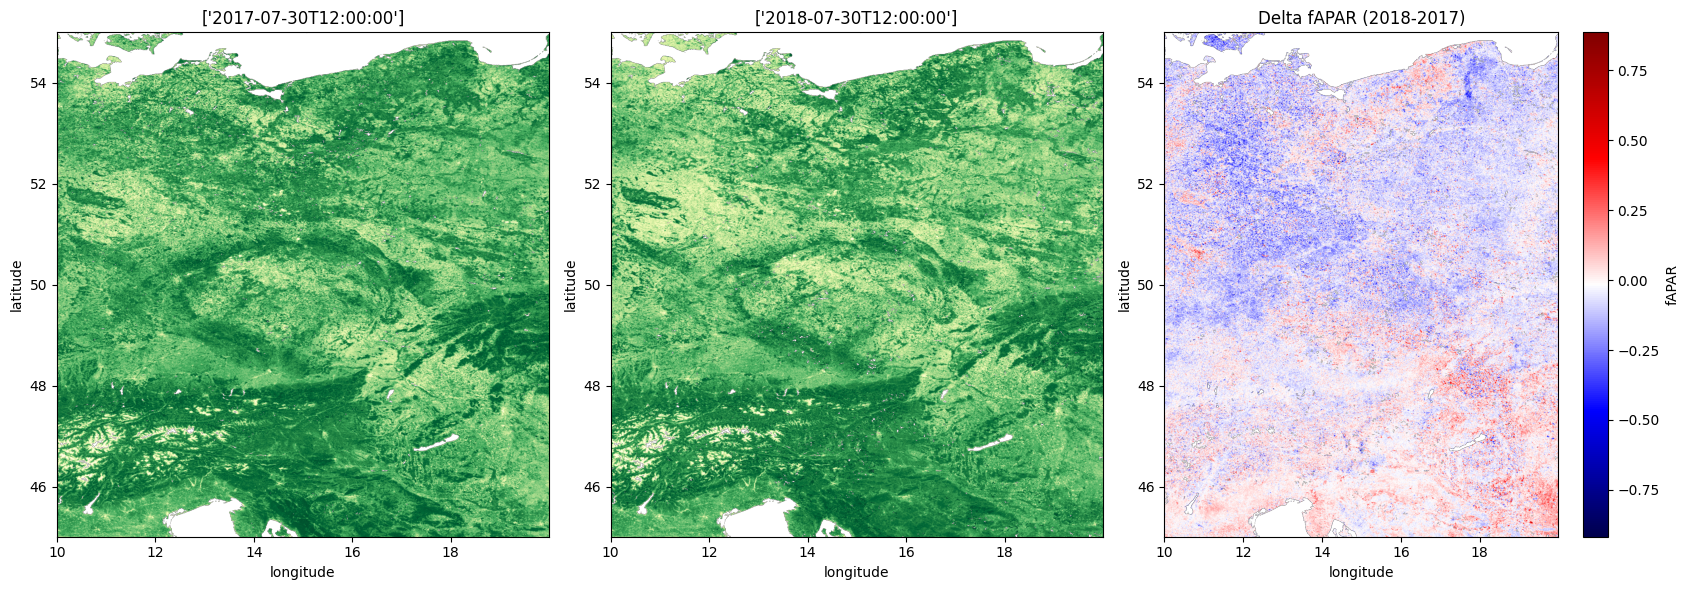

In [48]:
lon = ds["lon"]
lat = ds["lat"]
lon = lon.values
lat = lat.values

fig, ax = plt.subplots(1, 3, figsize=(17, 6))

#fig = plt.gcf()
#fig.set_size_inches(18.5, 5.5)

for i in range(3): 
    plt.subplot(1,3,i+1)
    if i<2:
        data = fAPAR2[:,:,i]
        ax[i].set_title(times2[i])
        ax[i].imshow(data, 
                origin='upper', 
                aspect='auto', 
                #cmap='viridis',  vmin=0, vmax=1.0, 
                cmap='YlGn',  vmin=0, vmax=1.0, 
                extent=[lon.min(), lon.max(), lat.min(), lat.max()])
    else:
        data = fAPAR2[:,:,1]-fAPAR2[:,:,0]
        im = ax[i].imshow(data, 
                origin='upper', 
                aspect='auto', 
                cmap = 'seismic',
                #cmap='viridis'#,  vmin=0, vmax=1.0, 
                extent=[lon.min(), lon.max(), lat.min(), lat.max()])
        ax[i].set_title('Delta fAPAR (2018-2017)')
    ax[i].set_xlabel('longitude')
    ax[i].set_ylabel('latitude')
cbar = plt.colorbar(im)
cbar.set_label('fAPAR')

## 5. Using the quality flag
The 'invcode' data layer provides useful information about the retrieval of the data, such as whether a suitable prior from the previous time step was available or not, whether the retrieval was successful or not, and how good the correspondence was between the radiative transfer model and the data. This information is orginized as an 32-bit binary layer (but not all bits are used). 

When you load this layer, you will find an integer number. It is necessary to convert this number to a binary, and extract the relevant bit. The manual explains that it is advised to eliminate 'RETR_UNTRUSTED' data (bit 8). It is also possible to remove the 'RETR_LOW_QUALITY' (bit 9), but this is too restrictive and may also eliminate data that are fine. We will look at this later in more detail. Below we show a piece of code to filter 'bit 8' data out.

We will do this by changing the map of integers into a map of 13 binary values. For example, for one pixel 'invcode' looks like: <br>
'0000110010000' <br>
the right bit is bit0, the left bit is is bit12. In this example, flags (bit) 4, 7 and 8 are raised.

In the code below, we convert the 'invcode' layer from integer into an array of bits, and then filter based on bit numbers. We have to count backwards from the most right bit. s[-1] means: the most right bit, s[-9] means: the 8th bit when starting counting from the right. 

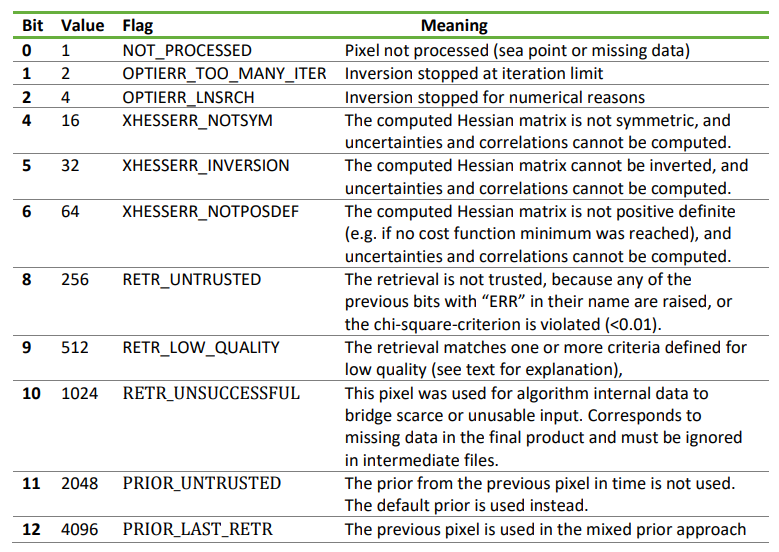



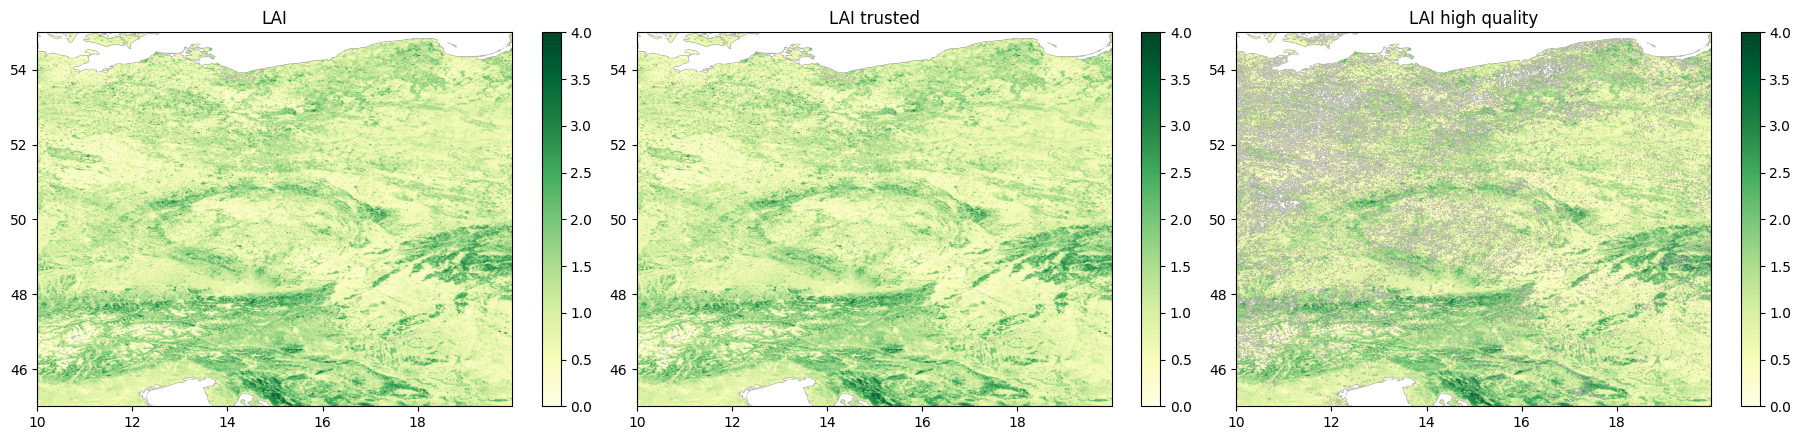

In [49]:
arr = QF2.astype(np.int64)
width = max(1, int(arr.max()).bit_length())
flat = arr.ravel(order='F')
bin_strs = np.array([format(int(v), f'0{width}b') for v in flat])
Q = bin_strs.reshape(arr.shape, order='F')  

untrusted_char_col = np.vectorize(lambda s: s[-9])(Q)   # -9: this is bit 8. [0000000000000]
bits = (untrusted_char_col == '1').astype(int)
LAI_TRUSTED2 = np.ma.masked_where(bits == 1, LAI2)

lowquality_char_col = np.vectorize(lambda s: s[-10])(Q)   # -9: this is bit 8. [0000000000000]
bits = (lowquality_char_col == '1').astype(int)
LAI_HIGHQUALITY2 = np.ma.masked_where(bits == 1, LAI2)

fig = plt.gcf()
fig.set_size_inches(18.5, 4.5)
for i in range(3): 
    plt.subplot(1,3,i+1)
    if i==0:
        data = LAI2[:,:,0]
        figtitle = 'LAI'
    if i ==1:
        data = LAI_TRUSTED2[:,:,0]
        figtitle = 'LAI trusted'
    if i ==2:
        data = LAI_HIGHQUALITY2[:,:,0]
        figtitle = 'LAI high quality'
    plt.title(figtitle)
#    print(title)
    im = plt.imshow(data, 
                origin='upper', 
                aspect='auto', 
                #cmap='viridis',  vmin=0, vmax=1.0, 
                cmap='YlGn',  vmin=0, vmax=4, 
                extent=[lon.min(), lon.max(), lat.min(), lat.max()])
    cbar = plt.colorbar(im)


## 6. Spatial aggregation

For some climate applications, the resulution of 1-km is impractially high. Below we show a simple approach to aggregate the data to 0.1 degree resultion, per tile separately. No other reprojection is done. The aggregation is a simple avaraging over pixels, of both LAI and the uncertainty of LAI. For more details, it is recommended to follow the following exercise as well: https://github.com/ecmwf-training/c3s-training-submodule-sat-obs-land/blob/main/lai-fapar-mean-with-inverse-variance-weights.ipynb

Here we use an inverse variance weigthed average,  which implies that data points with high uncertainty will contribute less to the area average.
Following the procedure described in the link above:
\begin{equation}
\hat{y} = \frac{\sum_i y_i/\sigma_{i}^2}{\sum_i 1/\sigma_{i}^2}.
\end{equation}
The variance of $\hat{y}$ is
\begin{equation}
Var(\hat{y}) = \frac{1}{\sum_i 1/\sigma_{i}^2}.
\end{equation}




In [11]:
new_pixel_size = 0.1
x = len(lon)
y = len(lat)
print('Current x-size', x)
print('Current y-size', y)
current_pixel_size_x = (lon[-1]-lon[0]) / (x - 1)
current_pixel_size_y = (lat[0]-lat[-1]) / (y - 1)
print('Current pixel size, x-direction', current_pixel_size_x)
print('Current pixel size, y-direction', current_pixel_size_y)
print('New pixel size', new_pixel_size)
x_new = round(current_pixel_size_x * x / new_pixel_size)
y_new = round(current_pixel_size_y * y / new_pixel_size)
x_tile = int(x / x_new)
y_tile = int(y / y_new)
x_new = int(x / x_tile)
y_new = int(y / y_tile)
print('New x-size', x_new)
print('New y-size', y_new)
print('Tile x-size', x_tile)
print('Tile y-size', y_tile)

Current x-size 1120
Current y-size 1120
Current pixel size, x-direction 0.008928572
Current pixel size, y-direction 0.00892857
New pixel size 0.1
New x-size 101
New y-size 101
Tile x-size 11
Tile y-size 11


In [24]:
# Create and fill aggregated array, using the pixel data from LAI_TRUSTED as the source
LAI_aggregated = np.empty((y_new, x_new))
LAI_err_aggregated = np.empty((y_new, x_new))
for x in range(0, x_new):
    x1 = x*x_tile
    x2 = (x+1)*x_tile
    for y in range(0, y_new):
        y1 = y*y_tile
        y2 = (y+1)*y_tile
        # [y1:y2,x1:x2] is now the x_tile x y_tile moving window to compute the "mean" (in our example 11x11 pixels)
        # LAImean = np.nansum(LAI_TRUSTED[y1:y2,x1:x2]/np.power(LAI_err[y1:y2,x1:x2],2))/np.nansum(1.0/np.power(LAI_err[y1:y2,x1:x2],2))
        I = np.nonzero(np.isnan(LAI_TRUSTED2[y1:y2,x1:x2]))[0]
        if I.size < 10:
            variance = 1. / np.nansum((1. / LAI_err2[y1:y2,x1:x2]**2))
            LAImean = np.nansum((LAI_TRUSTED2[y1:y2,x1:x2] /  LAI_err2[y1:y2,x1:x2]**2)) / np.nansum((1 /  LAI_err2[y1:y2,x1:x2]**2))
            LAIerrmean = np.sqrt(variance)
            #LAImean = np.nanmean(LAI_TRUSTED2[y1:y2,x1:x2])
            #LAImean = np.ma.filled(LAImean, np.nan)
        
            #LAIerrmean = np.nanmean(LAI_err2[y1:y2,x1:x2])        
            #LAIerrmean = np.ma.filled(LAIerrmean, np.nan)
        else:
            LAImean = np.nan
            LAIerrmean = np.nan
        LAI_aggregated[y,x] = LAImean
        LAI_err_aggregated[y,x] = LAIerrmean
        

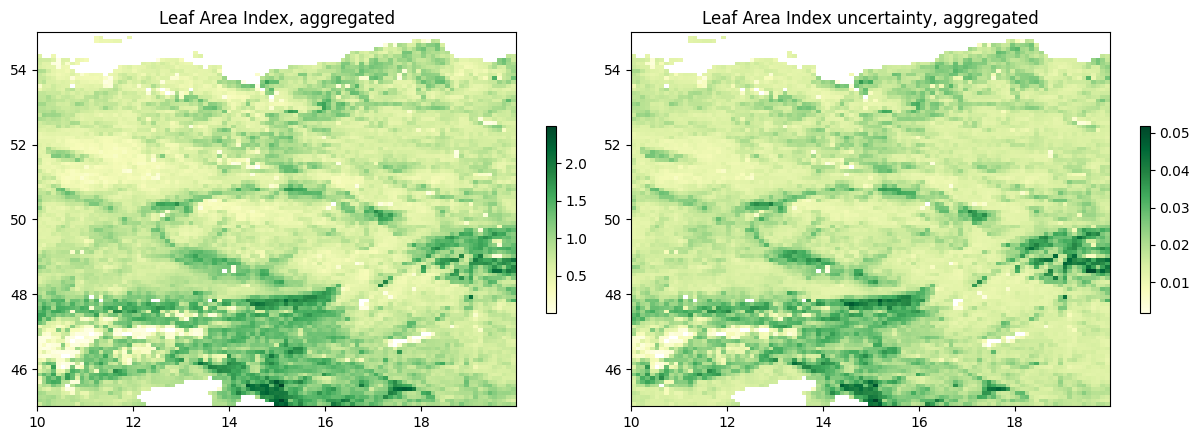

In [25]:
fig = plt.gcf()
fig.set_size_inches(12.5, 4.5)
plt.subplot(1,2,1)
im = plt.imshow(LAI_aggregated, 
                origin='upper', 
                aspect='auto', 
                #cmap='viridis',  vmin=0, vmax=1.0, 
                cmap='YlGn',#  vmin=0, vmax=1.0, 
                extent=[lon.min(), lon.max(), lat.min(), lat.max()])
cbar = plt.colorbar(shrink=0.5)
#plt.colorbar(shrink=0.9)
t = plt.title('Leaf Area Index, aggregated')

plt.subplot(1,2,2)
im = plt.imshow(LAI_err_aggregated, 
                origin='upper', 
                aspect='auto', 
                #cmap='viridis',  vmin=0, vmax=1.0, 
                cmap='YlGn',#  vmin=0, vmax=1.0, 
                extent=[lon.min(), lon.max(), lat.min(), lat.max()])
cbar = plt.colorbar(shrink=0.5)
#plt.colorbar(shrink=0.9)
t = plt.title('Leaf Area Index uncertainty, aggregated')


## 7. Time series of a selected region
We now access the Vegetation CCI+ CRPD-2 dataset for a geographical location in Portugal. We will look at a time period before and after a large bushfire event. We will:

1. select a small subset of the pixels of interest
2. plot time series
3. carry out temporal smoothing


In [50]:
tile = 'X17Y04'

We are skipping the step here to download the data, assuming they are already downloaded via the provided [link](https://surfdrive.surf.nl/s/AXyGmKdZK3P6bie) and stored locally. We loop through the available files and load only a slice of the data, with specific latitude and longitude, as:
__subset = ds[vars[2*k]].sel(lat=slice(40.0, 39.9), lon=slice(-8.3, -8.2))__


In [51]:
files = sorted(glob(r"*X17Y04*.nc"))
#print(files)
times = np.zeros((len(files),1), dtype="datetime64[s]")

vars = ['fAPAR', 'fAPAR_ERR', 'LAI', 'LAI_ERR']

for i, fp in enumerate(files, start=0): 
#for i in range(1): 
    print(fp)
    ds = xr.open_dataset(fp)  
    invcode = ds['invcode'].sel(lat=slice(40.0, 39.9), lon=slice(-8.3, -8.2))    
    invcode = np.squeeze(invcode.values)
 
    for k in range(2):
        subset = ds[vars[2*k]].sel(lat=slice(40.0, 39.9), lon=slice(-8.3, -8.2))
        subset_err = ds[vars[2*k+1]].sel(lat=slice(40.0, 39.9), lon=slice(-8.3, -8.2))
               
        var = np.squeeze(subset.values)
        var_err = np.squeeze(subset_err.values)
        if k ==0:
            if i==0:
                fAPAR = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
                fAPAR_err = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
                LAI = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
                LAI_err = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
                QF = np.zeros((subset.shape[1], subset.shape[2], len(files)), dtype=float)
            fAPAR[:,:,i] = var
            fAPAR_err[:,:,i] = var_err
            QF[:,:,i] = invcode
        else:
            LAI[:,:,i] = var
            LAI_err[:,:,i] = var_err        
    t = ds["time"]
    times[i] = t.isel(time=0).values

We will now apply the quality flag as before, and filter the data using the flags for untrusted and low quality

In [80]:
arr = QF.astype(np.int64)
width = max(1, int(arr.max()).bit_length())
flat = arr.ravel(order='F')
bin_strs = np.array([format(int(v), f'0{width}b') for v in flat])
Q = bin_strs.reshape(arr.shape, order='F')  

untrusted_char_col = np.vectorize(lambda s: s[-9])(Q)   # -9: this is bit 8. [0000000000000]
bits = (untrusted_char_col == '1').astype(int)
LAI_TRUSTED = np.ma.masked_where(bits == 1, LAI)
fAPAR_TRUSTED = np.ma.masked_where(bits == 1, fAPAR)

lowquality_char_col = np.vectorize(lambda s: s[-10])(Q)   # -9: this is bit 8. [0000000000000]
bits = (lowquality_char_col == '1').astype(int)
LAI_HIGHQUALITY = np.ma.masked_where(bits == 1, LAI)
fAPAR_HIGHQUALITY = np.ma.masked_where(bits == 1, fAPAR)

We now select the latitude and longitude of the small study area

In [81]:
ds = xr.open_dataset(files[0])  
lon = ds["lon"].sel(lon=slice(-8.3,-8.2))
lat = ds["lat"].sel(lat=slice(40,39.9))
lon = lon.values
lat = lat.values
#print(ds)

In this area, a severe fire took place in June 2017. We plot the fAPAR just before and just after the fire.

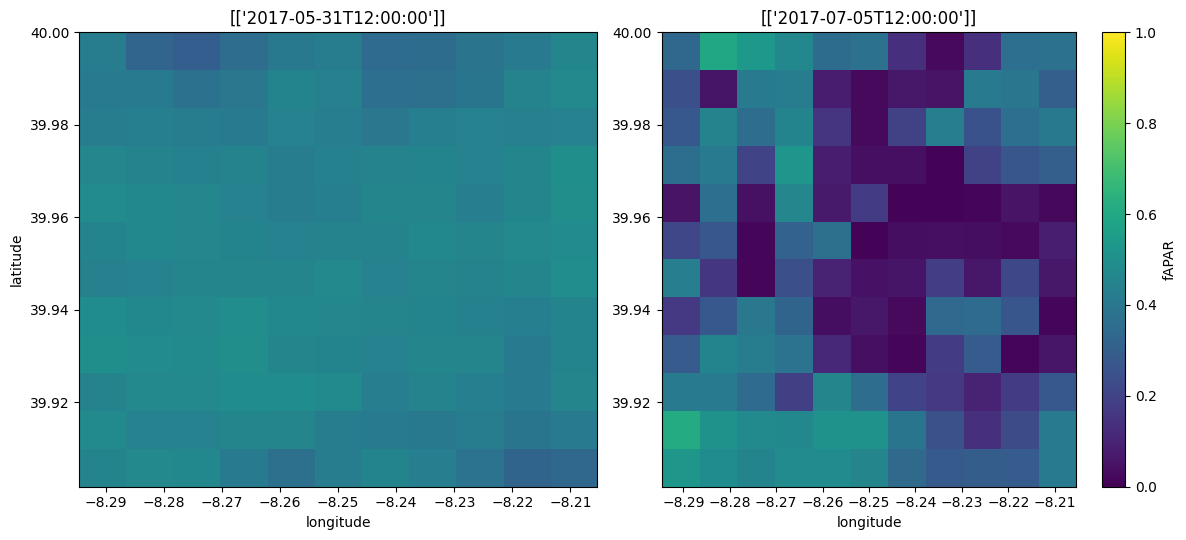

In [82]:
fig = plt.gcf()
fig.set_size_inches(12, 5.5)

plt.subplot(1,2,1)
I = np.nonzero((doy == 151) & (years==2017))[0]

im = plt.imshow(fAPAR[:,:,I], 
                origin='lower', 
                aspect='auto', 
                cmap='viridis',  vmin=0, vmax=1.6, 
                extent=[lon.min(), lon.max(), lat.min(), lat.max()])
plt.title(times[I])
plt.xlabel('longitude')
plt.ylabel('latitude')

plt.subplot(1,2,2)
I = np.nonzero((doy == 186) & (years==2017))[0]
im = plt.imshow(fAPAR[:,:,I], 
                origin='upper', 
                aspect='auto', 
                cmap='viridis',  vmin=0, vmax=1.0, 
                extent=[lon.min(), lon.max(), lat.min(), lat.max()])
plt.title(times[I])
plt.xlabel('longitude')
#plt.colorbar(im) 
cbar = plt.colorbar(im)
cbar.set_label('fAPAR')



We now take a look at the longer time series, and plot the average of the pixels in the small study area. We also calculate a smooth seasonal cycle for the 6 years before the fire. Then we plot:
- the time series of LAI and fAPAR with their uncertainty margins
- the seasonal cycles for the period 2011-206 as well as 2017, 2018, 2019 and 2020 separately

In [83]:
y = np.nanmean(fAPAR_HIGHQUALITY,axis=(0,1))
y_err = np.nanmean(fAPAR_err,axis=(0,1))
doy = (times - times.astype('datetime64[Y]')).astype('timedelta64[D]').astype(int) + 1
years = times.astype('datetime64[Y]').astype(int) + 1970
udoy = np.unique(doy)
uyear = np.unique(years)
#y_my = y.reshape(len(udoy), len(uyear)), this does not work because leap years have one data point extra. Alternative below
y_ave = np.zeros((len(udoy),1))
for k in range(len(udoy)):
    I = np.nonzero(doy == udoy[k])[0]
    y_ave[k] = np.mean(y[I])  

In [84]:
def nw_smooth(t, y, t_pred, bandwidth):
    w = np.exp(-0.5 * ((t[:,None]-t_pred[None,:]) / bandwidth)**2)
    w /= w.sum(axis=0)
    return (w * y[:,None]).sum(axis=0)

In [85]:
I = np.nonzero(years < 2017)[0]
clim = nw_smooth(np.squeeze(doy[I]),y[I],udoy,8)

## 

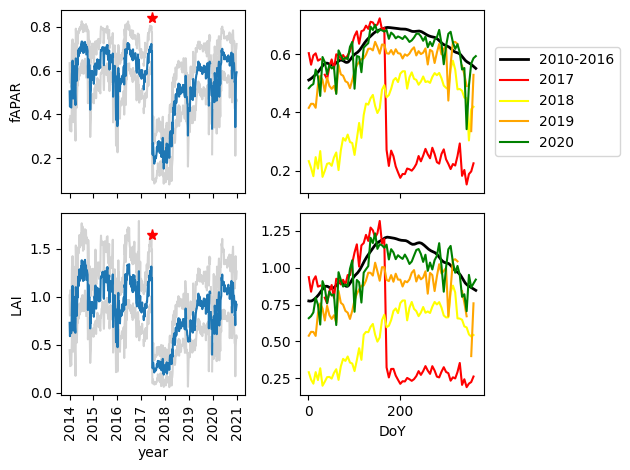

In [87]:
I = np.nonzero(years == 2017)[0]      # indices where year == val
colors = ['red', 'yellow' , 'orange', 'green']
#print(len(uyear))

for i in range(2):
    if i == 0:
        y = np.nanmean(fAPAR,axis=(0,1)) # pixel average
        y_err = np.nanmean(fAPAR_err,axis=(0,1))
        #y = np.squeeze(fAPAR[6,6,:])   # middle pixel
        #y_err = np.squeeze(fAPAR_err[6,6,:])
    else:
        #y = np.squeeze(LAI[6,6,:])
        #y_err = np.squeeze(LAI_err[6,6,:])
        y = np.nanmean(LAI,axis=(0,1))
        y_err = np.nanmean(LAI_err,axis=(0,1))
    for j in range(len(y)):    # remove data with more than 45 missing pixel values from the time series
        if np.count_nonzero(np.isnan(fAPAR[:,:,j]))>45:
            y[j] = np.nan
            
    # calculate climatology, using a simple smoothing filter.      
    I = np.nonzero(years < 2017) [0]
    I = I[~np.isnan(y[I])]
    clim = nw_smooth(np.squeeze(doy[I]),y[I],udoy,8)

    # plot results
    ax = plt.subplot(2,2,i*2+1)
    J = np.nonzero(years > 2013) [0]

   # fig = f.get_figure()
   # fig.set_size_inches(100, fig.get_size_inches()[0])  # set width only
    plt.plot(times[J],y[J]+y_err[J],color ='lightgray')
    plt.plot(times[J],y[J]-y_err[J],color='lightgray')
    plt.plot(times[J],y[J])
    plt.ylabel(vars[2*i])
    plt.xticks(rotation=90)
    if i ==1: plt.xlabel('year')
    if i ==0: 
        plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=False)
        #ax.get_xaxis().set_visible(False)

    plt.plot(times[545], y[544]+.15 + i*.3, '*', color = 'red', markersize = 8 )
    
    plt.subplot(2,2,i*2+2)
    plt.plot(udoy,clim, label = '2010-2016', linewidth=2 ,color = 'black')
    for k in range(7, len(uyear)): 
        val = uyear[k];
        J = np.nonzero(years == val)[0]      # indices where year == val
        plt.plot(doy[J],y[J], color = colors[k-7], label=str(val))
        #plt.plot(doy[J[y_err  [J]<0.3]],y[J[y_err[J]<0.3]], color = colors[k-5], label=str(val))
    
    if i ==1: plt.xlabel('DoY')
    if i ==0: 
        plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=False)
        plt.legend()
        plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))



We can futher inspect the quality of the data by looking at the orinal and the fitered time series, shown below all data (blue), trusted data (orange) and high quality data (green), for the middle pixel in the small study area. The filtering removes few data points.

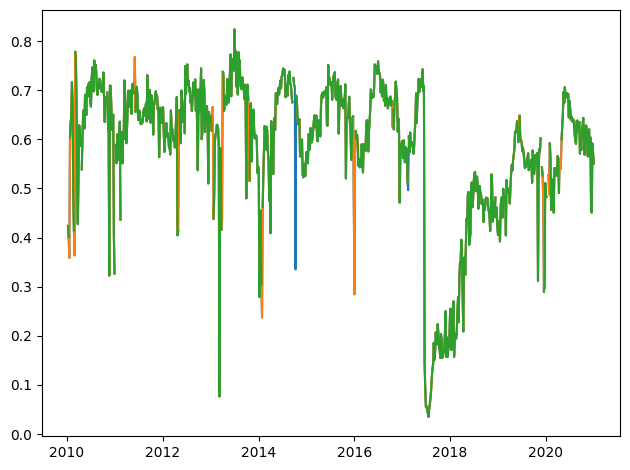

In [88]:
plt.plot(times, np.squeeze(fAPAR[6,6,:]))
plt.plot(times,np.squeeze(fAPAR_TRUSTED[6,6,:]))
plt.plot(times,np.squeeze(fAPAR_HIGHQUALITY[6,6,:]))


Although the time series is rather complete and smooth thanks to the use of multiple satellite missions, we may still be interesting in temporal smoothing. This is useful for for example phenology studies. Below we show the application of the harmonic analysis of time series (HANTS) to smooth the data. The first cell below is the function, the second cell below the application to the current time series.

The smoothness can be modified with the parameter 'nf', the number of harmonics. The lower this value, the smoother the function. A low value of nf may smoothen a discontinuity like the fire event, leading to an incorrect timing or more gradual effect of the fire in the smoothed data.

In [89]:
import numpy as np
from numpy.linalg import solve

def HANTS(ni, nb, nf, y, ts, HiLo, low, high, fet, dod, delta):
# HANTS processing
# Wout Verhoef, NLR, Remote Sensing Dept, June 1998
# Converted to MATLAB: Mohammad Abouali (2011). Python: C. van der Tol
# Modified: 
#   Apply suppression of high amplitudes for near-singular case by 
#	adding a number delta to the diagonal elements of matrix A, 
#	except element (1,1), because the average should not be affected 
#	Output of reconstructed time series in array yr June 2005 
#   Change call and input arguments to accommodate a base period length (nb)
#   All frequencies from 1 (base period) until nf are included
# 
# Inputs:
#   ni    = nr. of images (total number of actual samples of the time series)
#   nb    = length of the base period, measured in virtual samples (days, dekads, months, etc.)
#   nf    = number of frequencies to be considered above the zero frequency
#   y     = array of input sample values (e.g. NDVI values)
#   ts    = array of size ni of time sample indicators 
#           (indicates virtual sample number relative to the base period); 
#           numbers in array ts maybe greater than nb
#           If no aux file is used (no time samples), we assume ts(i)= i, 
#           where i=1, ..., ni
#   HiLo  = 2-character string indicating rejection of high or low outliers
#   low   = valid range minimum
#   high  = valid range maximum (values outside the valid range are rejeced right away)
#   fet   = fit error tolerance (points deviating more than fet from curve fit are rejected)
#   dod   = degree of overdeterminedness (iteration stops if number of 
#           points reaches the minimum required for curve fitting, plus dod). This is a safety measure
#   delta = small positive number (e.g. 0.1) to suppress high amplitudes
# 
# Outputs:
# 
#amp   = returned array of amplitudes, first element is the average of the curve
# phi   = returned array of phases, first element is zero
# yr	= array holding reconstructed time series
    
    # Initialize
    #y = np.asarray(y, dtype=float)
    #ts = np.asarray(ts, dtype=int)
    ts =  (ts-np.min(ts)) / (np.max(ts)-np.min(ts)) * nb
    
    sHiLo = -1 if HiLo == 'Hi' else (1 if HiLo == 'Lo' else 0)

    nr = min(2*nf + 1, ni)
    noutmax = ni - nr - dod
    dg = 180.0 / np.pi

    # build mat: shape (nr, ni)
    mat = np.zeros((nr, ni), dtype=np.float32)
    mat[0, :] = 1.0

    ang = 2.0 * np.pi * np.arange(nb) / nb
    cs = np.cos(ang)
    sn = np.sin(ang)

    for j in range(ni):
        t = int(ts[j].item())       
        for ii in range(0, nf):
            idx = (ii * t) % nb  
            mat[2*ii, j] = cs[idx]   
            mat[2*ii+1, j] = sn[idx] 

    # initial mask p: 1 = keep, 0 = reject
    p = np.ones(ni, dtype=float)
    mask = (y < low) | (y > high)
    p[mask] = 0.0
    nout = int((p == 0).sum())

    ready = False
    nloop = 0
    nloopmax = ni

    # precompute identity for regularization
    I_nr = np.eye(nr, dtype=float)

    while (not ready) and (nloop < nloopmax):
        nloop += 1
        za = mat.dot(p * y)               # shape (nr,)

        # A = mat * diag(p) * mat'  -> equivalent to (mat * p) @ mat.T where p multiplies columns
        mat_p = mat * p[np.newaxis, :]    # multiply each column j by p[j]
        A = mat_p.dot(mat.T)
        A = A + I_nr * delta
        A[0, 0] = A[0, 0] - delta         # undo regularization for first element

        zr = solve(A, za)                 # shape (nr,)

        yr = mat.T.dot(zr)                # fitted values, shape (ni,)

        diffVec = sHiLo * (yr - y)
        err = p * diffVec

        # sort ascending and get indices (like [~, rankVec] = sort(err, 'ascend'))
        rankVec = np.argsort(err)         # zero-based indices, smallest first

        maxerr = diffVec[rankVec[-1]]     # largest diffVec after sorting ascending
        ready = (maxerr <= fet) or (nout == noutmax)

        if not ready:
            i_idx = ni - 1
            j = rankVec[i_idx]
            # while (p(j)*diffVec(j)>maxerr*0.5)&&(nout<noutmax)
            while (p[j] * diffVec[j] > maxerr * 0.5) and (nout < noutmax):
                p[j] = 0.0
                nout += 1
                i_idx -= 1
                j = rankVec[i_idx]

    # prepare outputs
    amp = np.zeros(nf+1, dtype=np.float32)
    phi = np.zeros(nf+1, dtype=np.float32)

    amp[0] = zr[0]
    phi[0] = 0.0

    # ensure zr has length at least nr

    # compute amplitudes and phases from zr:
    for row in range(1, nr, 2):  
        ifr = (row + 1) // 2      # maps to frequency index 1..nf
        ra = zr[row]
        rb = zr[row + 1] if (row + 1) < len(zr) else 0.0
        amp[ifr] = np.sqrt(ra*ra + rb*rb)
        phase = np.degrees(np.arctan2(rb, ra))
        if phase < 0:
            phase += 360.0
        phi[ifr] = phase

    return amp, phi, yr

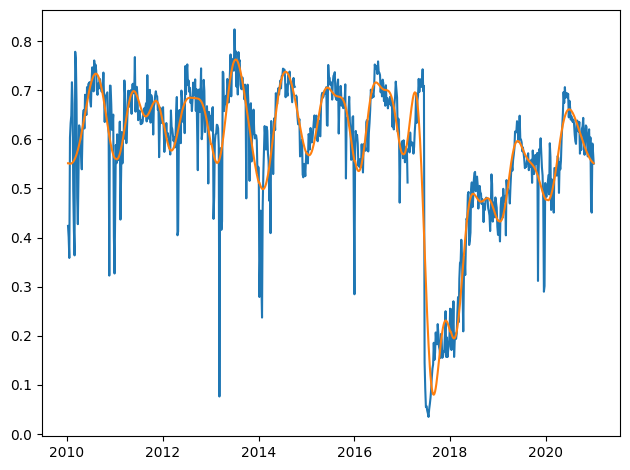

In [95]:
# application of HANTS algorith to the time series of Portugal. 
# Adjust the number of harmonics (nf) to decrease (higher nf) or increase (lower nf) the smoothness

y = np.squeeze(fAPAR_TRUSTED[6,6,:])
ni=len(y[~np.isnan(y)]);
nb=len(y[~np.isnan(y)]);
nf=25;
low=0.0;
high=255;
fet=5.0;
dod=1;
delta=0.1;

amp,phi,y_smooth=HANTS(ni,nb,nf,y[~np.isnan(y)],times[~np.isnan(y)],'none',low,high,fet,dod,delta);

plt.plot(times[~np.isnan(y)],y[~np.isnan(y)])
plt.plot(times[~np.isnan(y)],y_smooth)